In [3]:
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from glob import glob
import torch
import pickle

import re
from collections import Counter
from typing import List, Iterable, Dict, Optional, Tuple
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt
from torch.utils.data import random_split

import requests
from functools import partial


for pkg in ["averaged_perceptron_tagger", "averaged_perceptron_tagger_eng", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        try:
            nltk.data.find(f"taggers/{pkg}")
        except LookupError:
            nltk.download(pkg, quiet=True)

# Classification

## Custom Dataset

A custom Dataset class must implement three functions:
`__init__`, `__len__`, and
`__getitem__`.

Let's first upload IMDb dataset for binary sentiment classification.


In [ ]:
!wget http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

--2025-09-21 17:55:00--  http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  16.1MB/s    in 12s     

2025-09-21 17:55:12 (6.60 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]



In [ ]:
!tar -xzf aclImdb_v1.tar.gz

In [ ]:
!ls /content/aclImdb/train

labeledBow.feat  pos	unsupBow.feat  urls_pos.txt
neg		 unsup	urls_neg.txt   urls_unsup.txt


In [ ]:
!ls /content/aclImdb/test

labeledBow.feat  neg  pos  urls_neg.txt  urls_pos.txt


In [ ]:
!cat /content/aclImdb/train/pos/0_9.txt

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!

In [ ]:
!cat /content/aclImdb/train/neg/11813_1.txt

Before Stan Laurel became the smaller half of the all-time greatest comedy team, he laboured under contract to Broncho Billy Anderson in a series of cheapies, many of which were parodies of major Hollywood features. Following a dispute with Anderson, Laurel continued the informal series of parodies at Joe Rock's smaller (and more indigent) production company.<br /><br />Most of Laurel's parody films were only mildly funny at the time, and even less funny for modern audiences who haven't seen the original movie which Laurel is parodying. 'West of Hot Dog' is a fairly generic parody of cowboy shoot-'em-ups. It's marginally a specific parody of 'West of the Pecos', an oater released two years earlier with no major actors. Since 'West of the Pecos' was never a huge success, it's difficult to see why Stan's film unit chose this particular movie as a target for their lampoonery, much less why they waited so long after its release to parody it. And where did they get that title 'West of Hot D

We can see that texts with positive label are stored in `pos` dir and with negative in `neg` one.

Let's create the custom dataset class.

In [ ]:
class CustomTextDataset(Dataset):
    def __init__(self, base_dir, num_samples=None):
        if num_samples:
          pos_texts_path = glob(base_dir + "pos/*.txt")[:num_samples//2]
          neg_texts_path = glob(base_dir + "neg/*.txt")[:num_samples//2]
        else:
          pos_texts_path = glob(base_dir + "pos/*.txt")
          neg_texts_path = glob(base_dir + "neg/*.txt")
        self.texts_path = pos_texts_path + neg_texts_path

    def __len__(self):
        return len(self.texts_path)

    def __getitem__(self, idx):
        path = self.texts_path[idx]
        label = path.split('/')[-2]
        if label == "pos":
          target = 1
        elif label == "neg":
          target = 0
        else:
          raise ValueError(f"label should be 'pos' or 'neg', found {label}")
        with open(path, "r") as f:
          text = f.read()
        return text, target

In [ ]:
train_dataset = CustomTextDataset("/content/aclImdb/train/")

# Split the original test dataset into validation and test sets
test_dataset_full = CustomTextDataset("/content/aclImdb/test/", num_samples=2000)
val_size = int(0.5 * len(test_dataset_full)) # 50% for validation
test_size = len(test_dataset_full) - val_size # Remaining 50% for test
val_dataset, test_dataset = random_split(test_dataset_full, [val_size, test_size])

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 25000
Validation dataset size: 1000
Test dataset size: 1000


## Custom tokenizer using wordnet and lemming

In [ ]:
lemmatizer = WordNetLemmatizer()

def _to_wordnet_pos(tag: str):
    if tag.startswith("J"): return wn.ADJ
    if tag.startswith("V"): return wn.VERB
    if tag.startswith("N"): return wn.NOUN
    if tag.startswith("R"): return wn.ADV
    return wn.NOUN

_WORD_RE = re.compile(r"[A-Za-z']+")

def basic_tokenize(text: str) -> List[str]:
    return [m.group(0).lower() for m in _WORD_RE.finditer(text)]

def lemming(tokens: List[str]) -> List[str]:
    tagged = nltk.pos_tag(tokens)
    return [lemmatizer.lemmatize(tok, _to_wordnet_pos(pos)).lower() for tok, pos in tagged]

PAD = "<pad>"

class CustomTokenizer:
    def __init__(self, max_words: int = 1000, min_freq: int = 1):
        self.max_words = max_words
        self.min_freq = min_freq
        self.itos: List[str] = [PAD]  # PAD at 0
        self.stoi: Dict[str, int] = {PAD: 0}

    @property
    def pad_id(self) -> int:
        return 0

    @property
    def vocab_size(self) -> int:
      return len(self.itos)

    def fit(self, docs: Iterable[Tuple[str, int]]) -> None:
        cnt = Counter()
        for txt, _ in docs:
            cnt.update(lemming(basic_tokenize(txt)))
        words = [w for w, f in cnt.most_common() if f >= self.min_freq][: self.max_words]
        self.itos = [PAD] + words
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode_drop_oov(self, text: str) -> List[int]:
        seq = []
        for w in lemming(basic_tokenize(text)):
            idx = self.stoi.get(w)
            if idx is not None and idx != self.pad_id:  # drop OOV; never keep PAD
                seq.append(idx)
        return seq

    def decode(self, indices: torch.Tensor) -> List[List[str]]:
        """Decodes a batch of sequences of indices back to words."""
        decoded_batch = []
        for seq in indices:
            words = []
            for idx in seq:
                if idx < len(self.itos) and idx.item() != self.pad_id:
                    words.append(self.itos[idx.item()])
            decoded_batch.append(words)
        return decoded_batch

    def __call__(self, texts: Iterable[str], max_len: int) -> torch.Tensor:
        out = torch.full((len(texts), max_len), self.pad_id, dtype=torch.int)

        for i, text in enumerate(texts):
            idxs = self.encode_drop_oov(text)
            if not idxs:
                continue  # stays all PADs
            token_len = min(len(idxs), max_len)
            out[i, :token_len] = torch.tensor(idxs[:token_len], dtype=torch.int)
        return out

    def save_to(self, path: str):
      with open(path, "wb") as f:
        pickle.dump({
            "itos": self.itos,
            "stoi": self.stoi,
            "max_words": self.max_words,
            "min_freq": self.min_freq
        }, f)

    @classmethod
    def from_pretrained(cls, path: str) -> "CustomTokenizer":
        with open(path, "rb") as f:
            data = pickle.load(f)
        tokenizer = cls(max_words=data["max_words"], min_freq=data["min_freq"])
        tokenizer.itos = data["itos"]
        tokenizer.stoi = data["stoi"]
        return tokenizer

In [ ]:
# ---------- Collate: returns ONLY [B, L] LongTensor ----------
class FixedLenCollate:
    """
    Collate for raw strings:
      - encodes with tokenizer (dropping OOVs),
      - truncates/pads each to fixed length L,
      - returns a single Tensor of shape [B, L].
    """
    def __init__(self, tokenizer: CustomTokenizer, seq_len: int):
        self.tokenizer = tokenizer
        self.seq_len = int(seq_len)

    def __call__(self, batch: List[str]) -> Tuple[torch.Tensor, torch.Tensor]:
        texts, labels = zip(*batch)
        out = self.tokenizer(texts, max_len=self.seq_len)
        return out, torch.tensor(labels)

In [ ]:
tokenizer = CustomTokenizer(max_words=10000, min_freq=1)
tokenizer.fit(train_dataset)
tokenizer.save_to("tokenizer.pkl")

In [ ]:
tokenizer = CustomTokenizer.from_pretrained("tokenizer.pkl")

In [ ]:
# Test the tokenizer
sample_texts = [
    "This is a sample sentence to test the tokenizer.",
    "Another example sentence for testing.",
    "Short text.",
    "A longer sentence with more words to see how truncation works with the fixed length."
]

for sample_text in sample_texts:
    encoded_text = tokenizer([sample_text], max_len=8)
    print(f"Original text: {sample_text}")
    print(f"Encoded tokens: {encoded_text}")
    decoded_text = tokenizer.decode(encoded_text)[0]
    print(f"Decoded text: {' '.join(decoded_text)}\n")

Original text: This is a sample sentence to test the tokenizer.
Encoded tokens: tensor([[  11,    2,    3, 6938, 2304,    6, 1528,    1]], dtype=torch.int32)
Decoded text: this be a sample sentence to test the

Original text: Another example sentence for testing.
Encoded tokens: tensor([[ 154,  429, 2304,   16, 1528,    0,    0,    0]], dtype=torch.int32)
Decoded text: another example sentence for test

Original text: Short text.
Encoded tokens: tensor([[ 326, 2536,    0,    0,    0,    0,    0,    0]], dtype=torch.int32)
Decoded text: short text

Original text: A longer sentence with more words to see how truncation works with the fixed length.
Encoded tokens: tensor([[   3, 1658, 2304,   17,   50,  373,    6,   33]], dtype=torch.int32)
Decoded text: a longer sentence with more word to see



In [ ]:
collate = FixedLenCollate(tokenizer, seq_len=64)
batch_size = 1024
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate)

In [ ]:
next(iter(train_dataloader))

(tensor([[  17,   11,  166,  ...,   14,    2,    1],
         [ 790, 5521, 2059,  ...,  371,   26,    8],
         [   9,    2,   20,  ..., 1725,  630,    3],
         ...,
         [ 461,   10,  102,  ...,   12,    9,  475],
         [  87,  887,   40,  ...,   14,   82,   20],
         [ 297,   48,  174,  ...,    5,   22,  195]], dtype=torch.int32),
 tensor([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
         0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
         0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
         1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
         0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
         1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
         0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
         1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,

## RNN for classification

In [ ]:
class ClassificationRNN(nn.Module):
    def __init__(self, embedding_dim, hidden_size, output_size, vocab_size, pad_id=0, num_layers=1, bidirectional=False):
        super(ClassificationRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers=num_layers, bidirectional=bidirectional, batch_first=True)

        # Adjust the linear layer input size for bidirectional RNN
        self.h2o = nn.Linear(hidden_size * (2 if bidirectional else 1), output_size)
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.hidden_size = hidden_size

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)

        # Combine hidden states from different layers and directions
        if self.bidirectional:
            # Concatenate the forward and backward hidden states from the last layer
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            # Use the hidden state from the last layer
            hidden = hidden[-1,:,:]

        output = self.h2o(hidden)
        return output

In [ ]:
embedding_dim = 100
hidden_size = 128
output_size = 1  # Binary classification (positive/negative)
learning_rate = 0.003
num_epochs = 5

model = ClassificationRNN(embedding_dim, hidden_size, output_size, tokenizer.vocab_size, pad_id=tokenizer.pad_id, num_layers=2, bidirectional=True)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = "best_model.pth"

# training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (texts, labels) in enumerate(train_dataloader):
        texts, labels = texts.to(device), labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * texts.size(0)
        # Print loss every step
        print(f"Epoch {epoch+1}/{num_epochs}, Step {i+1}/{len(train_dataloader)}, Loss: {loss.item():.4f}")


    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Training Loss: {epoch_loss:.4f}")

    # validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        correct = 0
        total = 0
        for texts, labels in val_dataloader:  # Use val_dataloader for validation
            texts, labels = texts.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * texts.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).int()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_dataset) # Use val_dataset for validation size
        val_losses.append(epoch_val_loss)
        accuracy = correct / total
        print(f"Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {accuracy:.4f}")

        # Save the best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model to {best_model_path}")

print("Finished Training")

Epoch 1/5, Step 1/25, Loss: 0.6988
Epoch 1/5, Step 2/25, Loss: 0.7052
Epoch 1/5, Step 3/25, Loss: 0.7156
Epoch 1/5, Step 4/25, Loss: 0.7054
Epoch 1/5, Step 5/25, Loss: 0.6892
Epoch 1/5, Step 6/25, Loss: 0.6980
Epoch 1/5, Step 7/25, Loss: 0.7104
Epoch 1/5, Step 8/25, Loss: 0.6957
Epoch 1/5, Step 9/25, Loss: 0.6946
Epoch 1/5, Step 10/25, Loss: 0.6917
Epoch 1/5, Step 11/25, Loss: 0.6840
Epoch 1/5, Step 12/25, Loss: 0.6767
Epoch 1/5, Step 13/25, Loss: 0.6773
Epoch 1/5, Step 14/25, Loss: 0.6873
Epoch 1/5, Step 15/25, Loss: 0.6703
Epoch 1/5, Step 16/25, Loss: 0.6772
Epoch 1/5, Step 17/25, Loss: 0.6661
Epoch 1/5, Step 18/25, Loss: 0.6777
Epoch 1/5, Step 19/25, Loss: 0.6713
Epoch 1/5, Step 20/25, Loss: 0.6704
Epoch 1/5, Step 21/25, Loss: 0.6632
Epoch 1/5, Step 22/25, Loss: 0.6699
Epoch 1/5, Step 23/25, Loss: 0.6661
Epoch 1/5, Step 24/25, Loss: 0.6644
Epoch 1/5, Step 25/25, Loss: 0.6727
Epoch 1/5, Average Training Loss: 0.6842
Validation Loss: 0.6633, Validation Accuracy: 0.6130
Saved best mode

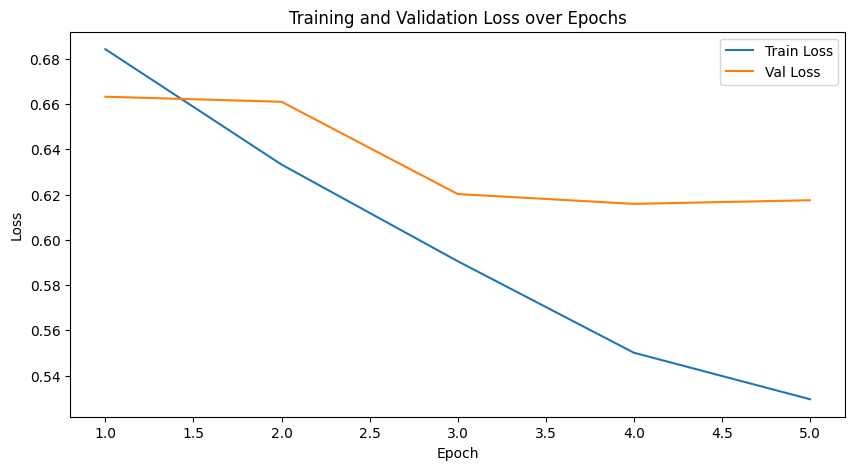

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

In [ ]:
# Load the best model
model = ClassificationRNN(embedding_dim, hidden_size, output_size, tokenizer.vocab_size, pad_id=tokenizer.pad_id, num_layers=2, bidirectional=True)
model.load_state_dict(torch.load(best_model_path))
model.to(device)

# Evaluate on the test set
model.eval()
running_test_loss = 0.0
with torch.no_grad():
    correct = 0
    total = 0
    for texts, labels in test_dataloader:
        texts, labels = texts.to(device), labels.to(device).float().unsqueeze(1)
        outputs = model(texts)
        loss = criterion(outputs, labels)
        running_test_loss += loss.item() * texts.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).int()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_test_loss = running_test_loss / len(test_dataset)
    accuracy = correct / total
    print(f"Final Test Loss: {epoch_test_loss:.4f}, Final Test Accuracy: {accuracy:.4f}")

Final Test Loss: 0.6084, Final Test Accuracy: 0.6750


# Language Modeling

## n-gram LM

Before you saw an n-gram LM which trained on "The City" (Pidmohylny novel). The model generated the following text from the input word "Степан":

> Степан подався на обличчі в сліди предків. Вчора він, з гірким махорочним пилом. Все це має? Нічого, крім виступу запрошених артистів, улаштувати й гаманця, бо життя невидним, потайним, але вибирати не зрозумів, що швидко складаючи рядки, непомітно день у природу, де сунулась вперед і на нього симпатію, бо виглядала його, де саме ім’я і ретушування, яка його з босяцькою щирістю розповів — конче потрібні! Але лихо його думку, не сподівалась уже виконувати приписи закону, то вільні були жадібними очима трамвай, що сам себе до висновку, що сиділи вздовж будинків, таких крихітних і спізнав. Підупала від віку тополя чудно та наради, що

Let's now train a LM using RNN and compare them.


## RNN LM

We are going to train a language model on the Ukrainian corpus from "https://github.com/robinhad/ucu-nlp-course/blob/main/data/city.txt" using a custom word tokenizer implemented from scratch.

## Ukrainian tokenizer

In [4]:
class SimpleWordTokenizer:
    def __init__(self, special_tokens=None):
        self.special_tokens = ["[PAD]"]
        if special_tokens:
            for token in special_tokens:
                if token not in self.special_tokens:
                    self.special_tokens.append(token)

        self.vocab = {token: i for i, token in enumerate(self.special_tokens)}
        self._reverse_vocab = {i: token for token, i in self.vocab.items()}
        self.pad_id = self.vocab["[PAD]"]
        self._split_regex = re.compile(r"(\w+'?\w*|\s|\S)")

    @property
    def vocab_size(self) -> int:
        return len(self.vocab)

    def fit(self, corpus: List[str], min_freq: int = 1) -> None:
        """Builds the vocabulary from a corpus."""
        word_counts = Counter()
        for text in corpus:
            words = self._split_regex.findall(text)
            word_counts.update(words)

        words = [w for w, f in word_counts.most_common() if f >= min_freq and w not in self.special_tokens]

        for word in words:
            if word not in self.vocab:
                self.vocab[word] = len(self.vocab)

        self._reverse_vocab = {v: k for k, v in self.vocab.items()}

    def encode(self, text: str) -> List[int]:
        """Encodes text using the trained vocabulary."""
        words = self._split_regex.findall(text)
        encoded_tokens = [self.vocab.get(word, self.pad_id) for word in words]
        return encoded_tokens

    def decode(self, token_ids: List[int]) -> str:
        """Decodes a list of token IDs back to text."""
        decoded_words = [self._reverse_vocab.get(token_id, "[PAD]") for token_id in token_ids]
        return "".join(decoded_words)

    def __call__(self, text: str) -> List[int]:
        return self.encode(text)

In [5]:
corpus_url = "https://raw.githubusercontent.com/robinhad/ucu-nlp-course/main/data/city.txt"

try:
    response = requests.get(corpus_url)
    response.raise_for_status()
    corpus_text = response.text
    corpus = corpus_text.splitlines()
    print(f"Downloaded corpus from {corpus_url}")
    print(f"Number of lines (documents) in corpus: {len(corpus)}")
except requests.exceptions.RequestException as e:
    print(f"Error downloading corpus: {e}")
    corpus = []

if corpus:
    simple_word_tokenizer = SimpleWordTokenizer()
    simple_word_tokenizer.fit(corpus)
    print(f"\nTrained Vocabulary Size: {simple_word_tokenizer.vocab_size}")
    with open("simple_word_tokenizer_ukrainian.pkl", "wb") as f:
        pickle.dump(simple_word_tokenizer, f)

    print("\nUkrainian SimpleWordTokenizer trained and saved to simple_word_tokenizer_ukrainian.pkl")
else:
    print("Corpus is empty. Tokenizer training skipped.")

Downloaded corpus from https://raw.githubusercontent.com/robinhad/ucu-nlp-course/main/data/city.txt
Number of lines (documents) in corpus: 2097

Trained Vocabulary Size: 21345

Ukrainian SimpleWordTokenizer trained and saved to simple_word_tokenizer_ukrainian.pkl


In [6]:
try:
    with open("simple_word_tokenizer_ukrainian.pkl", "rb") as f:
        simple_word_tokenizer = pickle.load(f)
    print("SimpleWordTokenizer loaded successfully.")
    print(f"Vocabulary size: {simple_word_tokenizer.vocab_size}")
except FileNotFoundError:
    print("Error: simple_word_tokenizer_ukrainian.pkl not found.")
    simple_word_tokenizer = None
except Exception as e:
    print(f"Error loading tokenizer: {e}")
    simple_word_tokenizer = None

if simple_word_tokenizer:
    # Define example Ukrainian sentences
    example_sentences = [
        "Це простий приклад речення для тестування токенізатора.",
        "Інше речення для перевірки невідомих слів абракадабра.",
        "Короткий текст.",
        "Ще один приклад з пунктуацією, наприклад, кома!"
    ]

    for sentence in example_sentences:
        encoded_tokens = simple_word_tokenizer.encode(sentence)
        decoded_text = simple_word_tokenizer.decode(encoded_tokens)

        print(f"\nOriginal Text: {sentence}")
        print(f"Encoded Tokens: {encoded_tokens}")
        print(f"Decoded Text: {decoded_text}")

    special_and_mixed_ids = [
        simple_word_tokenizer.pad_id,
        simple_word_tokenizer.vocab.get("приклад"),
        simple_word_tokenizer.vocab.get("невідомих"),
        99999,
        simple_word_tokenizer.pad_id
    ]

    decoded_special_and_mixed = simple_word_tokenizer.decode(special_and_mixed_ids)
    print(f"\nDecoding special and mixed IDs ({special_and_mixed_ids}):")
    print(f"Decoded Text: {decoded_special_and_mixed}")


SimpleWordTokenizer loaded successfully.
Vocabulary size: 21345

Original Text: Це простий приклад речення для тестування токенізатора.
Encoded Tokens: [63, 1, 2183, 1, 0, 1, 2245, 1, 54, 1, 0, 1, 0, 3]
Decoded Text: Це простий [PAD] речення для [PAD] [PAD].

Original Text: Інше речення для перевірки невідомих слів абракадабра.
Encoded Tokens: [0, 1, 2245, 1, 54, 1, 15390, 1, 3796, 1, 338, 1, 0, 3]
Decoded Text: [PAD] речення для перевірки невідомих слів [PAD].

Original Text: Короткий текст.
Encoded Tokens: [0, 1, 0, 3]
Decoded Text: [PAD] [PAD].

Original Text: Ще один приклад з пунктуацією, наприклад, кома!
Encoded Tokens: [298, 1, 272, 1, 0, 1, 13, 1, 0, 2, 1, 949, 2, 1, 0, 17]
Decoded Text: Ще один [PAD] з [PAD], наприклад, [PAD]!

Decoding special and mixed IDs ([0, None, 3796, 99999, 0]):
Decoded Text: [PAD][PAD]невідомих[PAD][PAD]


## Language modeling dataset

In [7]:
class UkrainianTextDataset(Dataset):
    def __init__(self, corpus_url, tokenizer, chunk_size=256):
        try:
            response = requests.get(corpus_url)
            response.raise_for_status()
            full_text = response.text.replace('\n', ' ')
            full_text = re.sub(r'\s+', ' ', full_text).strip()

            words = tokenizer._split_regex.findall(full_text)

            self.chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]

            print(f"Downloaded and chunked corpus from {corpus_url} into {len(self.chunks)} word chunks.")
        except requests.exceptions.RequestException as e:
            print(f"Error downloading corpus: {e}")
            self.chunks = []
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        return "".join(self.chunks[idx])

In [8]:
corpus_url = "https://raw.githubusercontent.com/robinhad/ucu-nlp-course/main/data/city.txt"
max_sequence_length = 100
train_dataset_lm = UkrainianTextDataset(corpus_url, simple_word_tokenizer, chunk_size=max_sequence_length)

Downloaded and chunked corpus from https://raw.githubusercontent.com/robinhad/ucu-nlp-course/main/data/city.txt into 1782 word chunks.


## Language model

In [9]:
class LanguageModelingLSTM(nn.Module):
    def __init__(self, embedding_dim, hidden_size, vocab_size, pad_id=0, num_layers=1, dropout=0.0):
        super(LanguageModelingLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers=num_layers, bidirectional=False, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_size)
        self.h2o = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        output, _ = self.lstm(x)
        output = self.norm(output)
        output = self.dropout(output)
        output = self.h2o(output)
        return output

In [10]:
def simple_word_collate_fn(batch: List[str], tokenizer: SimpleWordTokenizer, max_len: int) -> torch.Tensor:
    """
    Collate function for SimpleWordTokenizer.
    Encodes text samples, pads them to a fixed length, and returns a single tensor.
    """
    encoded_batch = [tokenizer.encode(text) for text in batch]

    # Pad sequences
    padded_batch = torch.full((len(encoded_batch), max_len), tokenizer.pad_id, dtype=torch.long)
    for i, seq in enumerate(encoded_batch):
        seq_len = min(len(seq), max_len)
        padded_batch[i, :seq_len] = torch.tensor(seq[:seq_len], dtype=torch.long)

    return padded_batch
batch_size_lm = 256
collate_fn_lm_simple = partial(simple_word_collate_fn, tokenizer=simple_word_tokenizer, max_len=max_sequence_length)
train_dataloader_lm_simple = DataLoader(train_dataset_lm, batch_size=batch_size_lm, shuffle=True, collate_fn=collate_fn_lm_simple)

In [11]:
device_lm = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the language model
embedding_dim_lm = 64
hidden_size_lm = 64
vocab_size_lm = simple_word_tokenizer.vocab_size
learning_rate_lm = 0.005
num_layers_lm = 2
dropout_prob_lm = 0.1


model_lm_simple = LanguageModelingLSTM(
    embedding_dim=embedding_dim_lm,
    hidden_size=hidden_size_lm,
    vocab_size=vocab_size_lm,
    pad_id=simple_word_tokenizer.pad_id,
    num_layers=num_layers_lm,
    dropout=dropout_prob_lm
)
model_lm_simple.to(device_lm)

criterion_lm_simple = nn.CrossEntropyLoss(ignore_index=simple_word_tokenizer.pad_id)

optimizer_lm_simple = optim.AdamW(model_lm_simple.parameters(), lr=learning_rate_lm)

In [ ]:
num_epochs_lm_simple = 20

for epoch in range(num_epochs_lm_simple):
    model_lm_simple.train()
    running_loss_lm_simple = 0.0

    for i, texts in enumerate(train_dataloader_lm_simple):
        texts = texts.to(device_lm)

        optimizer_lm_simple.zero_grad()

        # For language modeling, the target is the next token in the sequence
        inputs = texts[:, :-1]
        targets = texts[:, 1:]

        outputs_lm_simple = model_lm_simple(inputs)

        # Reshape outputs and targets for CrossEntropyLoss
        outputs_lm_simple = outputs_lm_simple.reshape(-1, vocab_size_lm)
        targets_lm_simple = targets.reshape(-1)

        loss_lm_simple = criterion_lm_simple(outputs_lm_simple, targets_lm_simple)
        loss_lm_simple.backward()
        optimizer_lm_simple.step()

        print(f"Epoch {epoch+1}/{num_epochs_lm_simple}, Step {i+1}/{len(train_dataloader_lm_simple)}, Loss: {loss_lm_simple.item():.4f}")

Epoch 1/20, Step 1/28, Loss: 0.7278
Epoch 1/20, Step 2/28, Loss: 0.7454
Epoch 1/20, Step 3/28, Loss: 0.7457
Epoch 1/20, Step 4/28, Loss: 0.7782
Epoch 1/20, Step 5/28, Loss: 0.7462
Epoch 1/20, Step 6/28, Loss: 0.7728
Epoch 1/20, Step 7/28, Loss: 0.7372
Epoch 1/20, Step 8/28, Loss: 0.7800
Epoch 1/20, Step 9/28, Loss: 0.7973
Epoch 1/20, Step 10/28, Loss: 0.7763
Epoch 1/20, Step 11/28, Loss: 0.7961
Epoch 1/20, Step 12/28, Loss: 0.7647
Epoch 1/20, Step 13/28, Loss: 0.8328
Epoch 1/20, Step 14/28, Loss: 0.8237
Epoch 1/20, Step 15/28, Loss: 0.7951
Epoch 1/20, Step 16/28, Loss: 0.7935
Epoch 1/20, Step 17/28, Loss: 0.8539
Epoch 1/20, Step 18/28, Loss: 0.8146
Epoch 1/20, Step 19/28, Loss: 0.8754
Epoch 1/20, Step 20/28, Loss: 0.8203
Epoch 1/20, Step 21/28, Loss: 0.8713
Epoch 1/20, Step 22/28, Loss: 0.8711
Epoch 1/20, Step 23/28, Loss: 0.8389
Epoch 1/20, Step 24/28, Loss: 0.9080
Epoch 1/20, Step 25/28, Loss: 0.8746
Epoch 1/20, Step 26/28, Loss: 0.8413
Epoch 1/20, Step 27/28, Loss: 0.8133
Epoch 1/20

In [12]:
torch.save(model_lm_simple.state_dict(), "final_lm_model.pth")

In [13]:
loaded_model_lm = LanguageModelingLSTM(
    embedding_dim=embedding_dim_lm,
    hidden_size=hidden_size_lm,
    vocab_size=vocab_size_lm,
    pad_id=simple_word_tokenizer.pad_id,
    num_layers=num_layers_lm,
    dropout=dropout_prob_lm
)

loaded_model_lm.load_state_dict(torch.load("final_lm_model.pth"))

loaded_model_lm.to(device_lm)

LanguageModelingLSTM(
  (embedding): Embedding(21345, 64, padding_idx=0)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (h2o): Linear(in_features=64, out_features=21345, bias=True)
)

In [27]:
sum(i.numel() for i in loaded_model_lm.parameters())

2820193

## Sample

In [18]:
def generate_text(model, tokenizer, start_sequence: str, output_length: int, device: torch.device, temperature: float = 1.0) -> str:
    model.eval()
    encoded_start_sequence = tokenizer.encode(start_sequence)
    input_sequence = torch.tensor([encoded_start_sequence], dtype=torch.long).to(device)

    generated_sequence = encoded_start_sequence

    with torch.no_grad():
        for _ in range(output_length):
            outputs = model(input_sequence)

            # outputs shape is [batch_size, sequence_length, vocab_size]
            last_token_logits = outputs[:, -1, :] # Shape [batch_size, vocab_size]

            if temperature == 0.0: # Greedy sampling
                next_token_id = torch.argmax(last_token_logits, dim=-1).item()
            else:
                scaled_logits = last_token_logits / temperature
                probabilities = F.softmax(scaled_logits, dim=-1)
                # Sample from the distribution
                next_token_id = torch.multinomial(probabilities, num_samples=1).squeeze().item()

            generated_sequence.append(next_token_id)

            input_sequence = torch.tensor([generated_sequence], dtype=torch.int).to(device)

    # Decode the generated sequence back into a string
    generated_text = tokenizer.decode(generated_sequence)

    return generated_text

In [19]:
def sample_lm(start_string, desired_output_length=100, temperature_value=1):
  generated_text_output = generate_text(
      model=loaded_model_lm,
      tokenizer=simple_word_tokenizer,
      start_sequence=start_string,
      output_length=desired_output_length,
      device=device_lm,
      temperature=temperature_value
  )

  print(f"Generated text:\n{generated_text_output}")

In [20]:
for _ in range(10):
  sample_lm("Степан")

Generated text:
Степан запитливо на нього глянула йому: — А селян чудовий фільм так було ще билось помешкання півтора оком розкішну рядки, де п’янив його. І коли він не постеріг бажання в словах молодого господарника бриніли, імпонували йому на місце. І за цю химеру проміняти науку, інститут, звести 
Generated text:
Степан почав оглядати аудиторію, силкуючись з обережності вирішивши його становища до цілковитого страху. Це те, Зосько, чому ж можна завжди жити. Зоська давала йому на вуста, запалюючи їх по черзі, мов сигнальні вогні. Він поволі схотілось пастку, щоб зруйнувала в Покірна передосінніх подихах. Вона випручнулась і
Generated text:
Степан, випадково в насолодою. Процес одягання, не почуваючи в його серці. В інституті його дивний справжнім розшаруватись, таку могутню розлогість вулиць й лекції і що з’являються він стало страшно, а нічого просто лише клаптики, вечеряти, але вузькими виявляти до неї тихенько взявся до ліжком. Я 
Generated text:
Степан. А наше зокрема рук. виверт

In [25]:
for _ in range(10):
  sample_lm("Світозаров")

Generated text:
Світозаров. А може, він нудьги? Зоська сказала, збираючись в темряву є. — Вам подобається! І дружина з Радченка хлопець шкода, його бажання — хотів гостя. Хлопець почував — те йолопом, що давно вже заполонив, з вуст в певності нагаєм, і потім виттям репаного рояля — 
Generated text:
Світозаров. А може, в неї дві, зрештою, на потрібні посада. Але занадто сказав він не більше розумом, ніж їх дивно, що висловити через двері пройняв і негайно до степів. Тепер часом ще уваги. Хай був доконаний. Така заборона, що людина й поступ. Але через такі
Generated text:
Світозаров. Коли мені хоче за чверть години, його дбайливо відзначити його духовного. "Це ж мені не бачити. — Приходь, ти, Стефочко, я візьму, що — спитав він. — Але я заздрю вам,— сказав поет.— Різниця між людиною та рослиною полягає, кажуть, у тім
Generated text:
Світозаров. Коли я мушу сміх, що Надійка будуть видимо зніяковило. Повагавшись бібліотеці, безпритульний, тебе з краще. До тих часів? І гордо відповів: — Бул

In [31]:
for _ in range(10):
  sample_lm("Михайло")

Generated text:
Михайло розпалювати? — але не це не... Взагалі я такий тонкий, але не почуваючи, тільки село пристрасно прихована над френча. — Зоська віщувала молоді Максим. Степан Радченко проти таку честь. Так не буде його. Навіщо ж це ж гарно свій інститут, що вдома було бути 
Generated text:
Михайло Але мусінька мій! Та він не сторінки — про все це думати. Тільки це можна було бути не піддуриш! Степан підбіг до столу, і тому двічі на нових боях, споглядає його зовсім не примічають! Степан разом з жахом почуваючи і тепер вулицями в своєму селі, де 
Generated text:
Михайло вітрин, таки відповів Степан. І радісно зрозумів, що не знав, які не дійшов, але здушений зойк знову, постерігав потрохи, що гаданий його спокій є в інституті. Але чудне піти його не зрозуміє щось й не думати. І зайшов у цю немудру схему ще з десять 
Generated text:
Михайло виграші в його збудженій одежі. Це була голова, одягаючись докором трохи попишатись собою ради його обов’язків по ті копійок та професор, що х